# Laboratory practice 4 (1 session)

<h3 style="font-size: 20px"> Important notes: </h3>



- This .pynb file is ready for execution in a Google Colab (https://colab.research.google.com) environment. Just upload it and open it from a regular Colab session.

- **This lab will be evaluated at the end of the session on April 17 (deadline).**

- In case we do not manage to evaluate all exercises during the lab session, the students will be asked to send the answers of Lab 4 (in PDF format) to the task in Poliformat. (Use the "print" menu option of the Google Colab environment to create a PDF file. **Please name the file with your answers as “Lab4_students_name.pdf”**)

In [20]:
# ALWAYS RUN THIS CELL AFTER YOU LOAD (OR RELOAD) THE NOTEBOOK

# Generic cell for correct operation of QCO materials in Google Colab (jcperez@disca.upv.es):
!pip -qqq install qiskit[visualization]
!pip -qqq install qiskit-aer
import qiskit
%matplotlib inline
qiskit.__version__

# Not always necessary (jcperez@disca.upv.es):
!pip -qqq install git+https://github.com/qiskit-community/qiskit-textbook.git#subdirectory=qiskit-textbook-src

# To fix a bug/version incompatibility in that file (jcperez@disca.upv.es):
# !sed -ie 's/denominator >/denominator() >/g' /usr/local/lib/python3.10/dist-packages/qiskit/visualization/array.py

# To set graphical circuit drawing by default in qiskit (jcperez@disca.upv.es):
!mkdir ${HOME}/.qiskit 2>/dev/null
!printf "[default]\ncircuit_drawer = mpl\ncircuit_mpl_style = iqp\n" > ${HOME}/.qiskit/settings.conf

  Preparing metadata (setup.py) ... done


In [21]:
from qiskit import *
from qiskit.visualization import plot_distribution
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from math import sqrt, pi
import numpy as np
from qiskit.quantum_info import Statevector, random_statevector
from qiskit.visualization import plot_distribution, plot_bloch_multivector
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister

<h2 style="font-size:24px;">The teleportation protocol</h2>

<br>
<div style="background: #E8E7EB; border-radius: 5px;
-moz-border-radius: 5px;">
  <p style="background: #800080;
            border-radius: 5px 5px 0px 0px;
            padding: 10px 0px 10px 10px;
            font-size:18px;
            color:white;
            "><b>Goal</b></p>
    <p style=" padding: 0px 0px 10px 10px;
              font-size:16px;">Understand how quantum teleportation works.</p>
</div>


<h3 style="font-size: 20px"> 1. Creating Bell pairs (1 point) </h3>



As discussed in the lectures, quantum teleportation is a protocol that allows to transfer a quantum state from the sender (Alice) to the receiver (Bob) by only sending two classical bits over a classical communication channel. It requires to create an entangled state called Bell state.

In this first exercise you will have to write the code for creating all four Bell pairs $|\beta_{00}\rangle$, $|\beta_{01}\rangle$ , $|\beta_{10}\rangle$ and $|\beta_{11}\rangle$.  


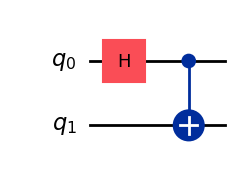

In [22]:

qc_Bellpair = QuantumCircuit(2)
#### your code goes here
## add as many code cells as needed to create ecah of the Bell pairs

##BP00
qc_Bellpair.h(0)
qc_Bellpair.cx(0,1)

# Let's view our circuit
qc_Bellpair.draw()


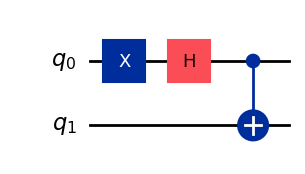

In [23]:
qc_Bellpair = QuantumCircuit(2)
##BP01
qc_Bellpair.x(0)
qc_Bellpair.h(0)
qc_Bellpair.cx(0,1)
qc_Bellpair.draw()

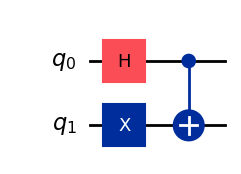

In [24]:
##BP10
qc_Bellpair = QuantumCircuit(2)
qc_Bellpair.x(1)
qc_Bellpair.h(0)
qc_Bellpair.cx(0,1)
qc_Bellpair.draw()

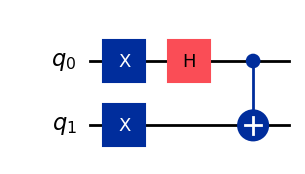

In [25]:
##BP11
qc_Bellpair = QuantumCircuit(2)
qc_Bellpair.x(0)
qc_Bellpair.x(1)
qc_Bellpair.h(0)
qc_Bellpair.cx(0,1)
qc_Bellpair.draw()

We can then use the Qiskit's statevector simulator to view the resulting two-qubit state.

In [26]:
backend = Aer.get_backend('statevector_simulator') # Tell Qiskit how to simulate our circuit
# Let's display the output state vector
result = backend.run(qc_Bellpair).result() # Do the simulation, returning the result
out_state = result.get_statevector()
print(out_state) # Display the output state vector


Statevector([ 0.        +0.00000000e+00j, -0.70710678+8.65956056e-17j,
              0.70710678-8.65956056e-17j,  0.        +0.00000000e+00j],
            dims=(2, 2))


<h3 style="font-size: 20px"> 2. Transfering quantum states: the teleportation protocol (4 points)</h3>



In this section, we will create the quantum circuit for teleporting a quantum state. In order to test its functionality, we will teleport the following quantum states (one after the other):

$$
\begin{aligned}
1. |\psi_{A} \rangle & = |0\rangle \\
2. |\psi_{B} \rangle & = |1\rangle \\
3. |\psi_{C} \rangle & = \tfrac{1}{2}|0\rangle + \tfrac{\sqrt{3}}{2}|1\rangle \\
4. |\psi_{D} \rangle & = Random
\end{aligned}
$$

Note that $|\psi_{D} \rangle$ is a random state that can be generated using the fuction `random_statevector` as we did in the previous lab.


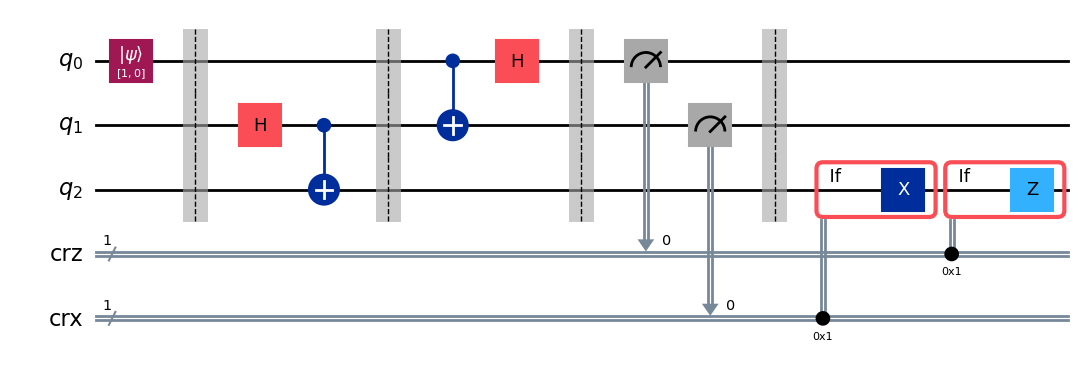

In [64]:
# Protocol uses 3 qubits and 2 classical bits in 2 different registers (measurement results are stored in two classical registers)
#The circuit has 3 qubits and 2 classical registers
qr = QuantumRegister(3, name='q')
crz, crx = ClassicalRegister(1, name="crz"), ClassicalRegister(1, name="crx")
teleportation_circuit = QuantumCircuit(qr,crz,crx)

#### your code goes here

## STEP1: initialization of the qubit to be sent (Alice's qubit)

#initial state A
initial_stateA = [1,0]

#initial state B
initial_stateB = [0,1]

#initial state C
initial_stateC = [1/2, sqrt(3)/2]

#initial state D
initial_stateD= random_statevector(2, seed = 2137)

#Apply initialisation operation to the 0th qubit
teleportation_circuit.initialize(initial_stateA, 0)
teleportation_circuit.barrier()


## STEP2: Creation of the Bell Pair
#### your code goes here

teleportation_circuit.h(1)
teleportation_circuit.cx(1,2)

teleportation_circuit.barrier()

## STEP3: Operations and measurements at Alice's side (CNOT and H)
#### your code goes here

teleportation_circuit.cx(0,1)
teleportation_circuit.h(0)

teleportation_circuit.barrier()

#measurements of qubits 0 and 1 see: https://docs.quantum.ibm.com/guides/measure-qubits
#### your code goes here

teleportation_circuit.measure(0, crz)
teleportation_circuit.measure(1, crx)

teleportation_circuit.barrier()

## STEP4: Corrections

#After receiving the two clasical bits, Bob will have to apply specific corrections to his qubit. These corrections are:
#00  →  Do nothing
#01  →  Apply  𝑋  gate
#10  →  Apply  𝑍  gate
#11  →  Apply  𝑍𝑋  gate

# Check the if_test instruction of Qiskit por performing the corrections https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit

#### your code goes here

with teleportation_circuit.if_test((crx, 1)) as else_:
    teleportation_circuit.x(2)
with teleportation_circuit.if_test((crz, 1)) as else_:
    teleportation_circuit.z(2)


teleportation_circuit.draw()

<h4 style="font-size: 17px">&#128211;Checking the results </h4>

In order to check that the intended state has been teleported, we can use the statevector simulator and observe that the state of $|q_2\rangle$ is the same as the state $|\psi\rangle$ we created, while the states of $|q_0\rangle$ and $|q_1\rangle$ have been collapsed to either $|0\rangle$ or $|1\rangle$. Please, run the code several times and take some snapshots of the Bloch spheres for different outcomes of qubits $|q_0\rangle$ and $|q_1\rangle$.

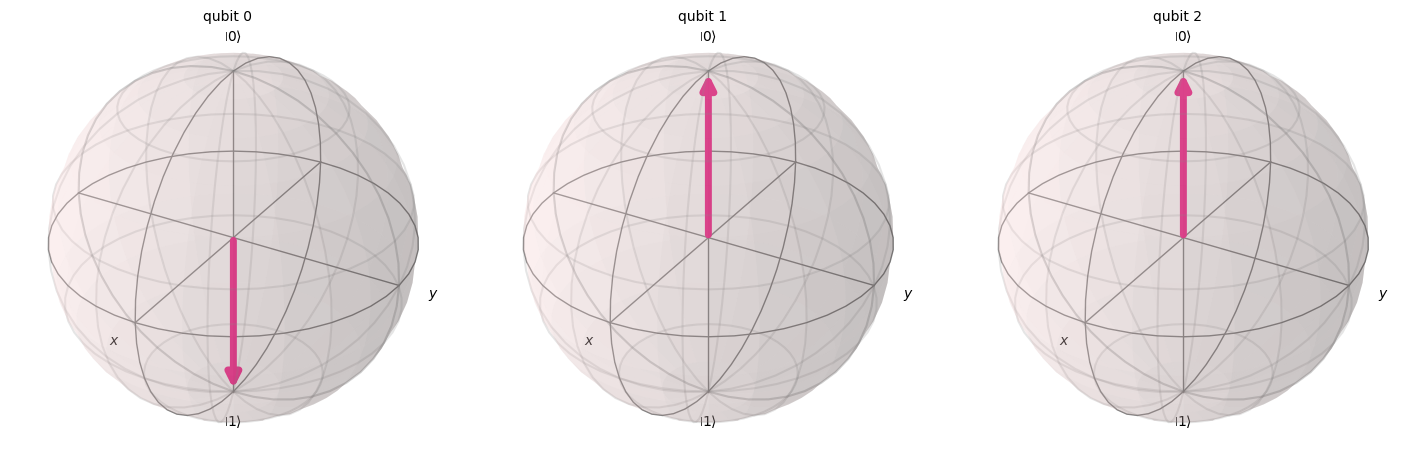

In [71]:
sv_sim = Aer.get_backend('statevector_simulator')
out_vector = sv_sim.run(teleportation_circuit).result().get_statevector()
plot_bloch_multivector(out_vector)

<h3 style="font-size: 20px"> 3. Teleporting quantum states using different Bell pairs (5 points) </h3>



In the previous section and in the lecture, we used the Bell pair $|\beta_{00}\rangle$ for teleporting a quantum state. However, as we have seen in Section 1, different Bell pairs exist and can be used in the teleportation circuit.

To see what happens when a different Bell pair is used, teleport the quantum state $|\psi_B \rangle = |1\rangle$ but now using the Bell state $|\beta_{10}\rangle$ ($|q_1 \rangle = |0\rangle$ and $|q_2 \rangle = |1\rangle$).

To this purpose, you can use the code writen in the previous section and just modify   `Step 2`.

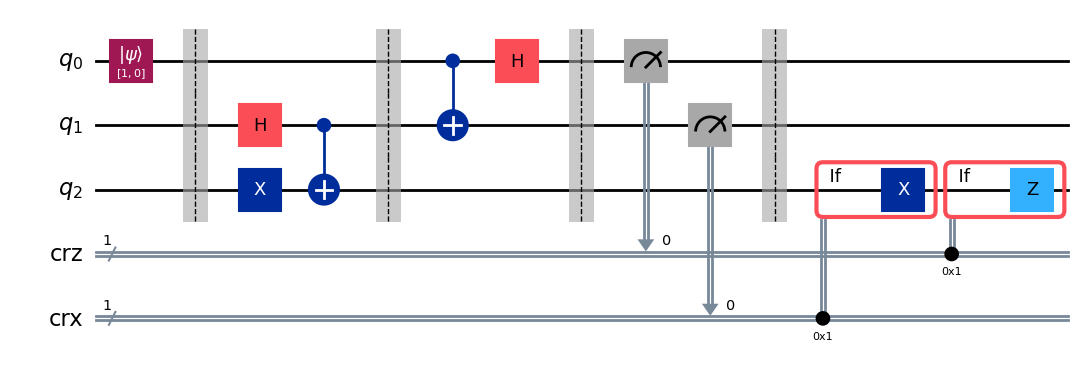

In [72]:
#### your code goes here

qr = QuantumRegister(3, name='q')
crz, crx = ClassicalRegister(1, name="crz"), ClassicalRegister(1, name="crx")
teleportation_circuit = QuantumCircuit(qr,crz,crx)

## STEP1: initialization of the qubit to be sent (Alice's qubit)

#initial state A
initial_stateA = [1,0]

#initial state B
initial_stateB = [0,1]

#initial state C
initial_stateC = [1/2, sqrt(3)/2]

#initial state D
initial_stateD= random_statevector(2)

#Apply initialisation operation to the 0th qubit
teleportation_circuit.initialize(initial_stateA, 0)
teleportation_circuit.barrier()


## STEP2: Creation of the Bell Pair
#### your code goes here

teleportation_circuit.h(1)
teleportation_circuit.x(2)
teleportation_circuit.cx(1,2)

teleportation_circuit.barrier()

## STEP3: Operations and measurements at Alice's side (CNOT and H)
#### your code goes here

teleportation_circuit.cx(0,1)
teleportation_circuit.h(0)

teleportation_circuit.barrier()

#measurements of qubits 0 and 1 see: https://docs.quantum.ibm.com/guides/measure-qubits
#### your code goes here

teleportation_circuit.measure(0, crz)
teleportation_circuit.measure(1, crx)

teleportation_circuit.barrier()

## STEP4: Corrections

#After receiving the two clasical bits, Bob will have to apply specific corrections to his qubit. These corrections are:
#00  →  Do nothing
#01  →  Apply  𝑋  gate
#10  →  Apply  𝑍  gate
#11  →  Apply  𝑍𝑋  gate

# Check the if_test instruction of Qiskit por performing the corrections https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit

#### your code goes here

with teleportation_circuit.if_test((crx, 1)) as else_:
    teleportation_circuit.x(2)
with teleportation_circuit.if_test((crz, 1)) as else_:
    teleportation_circuit.z(2)


teleportation_circuit.draw()


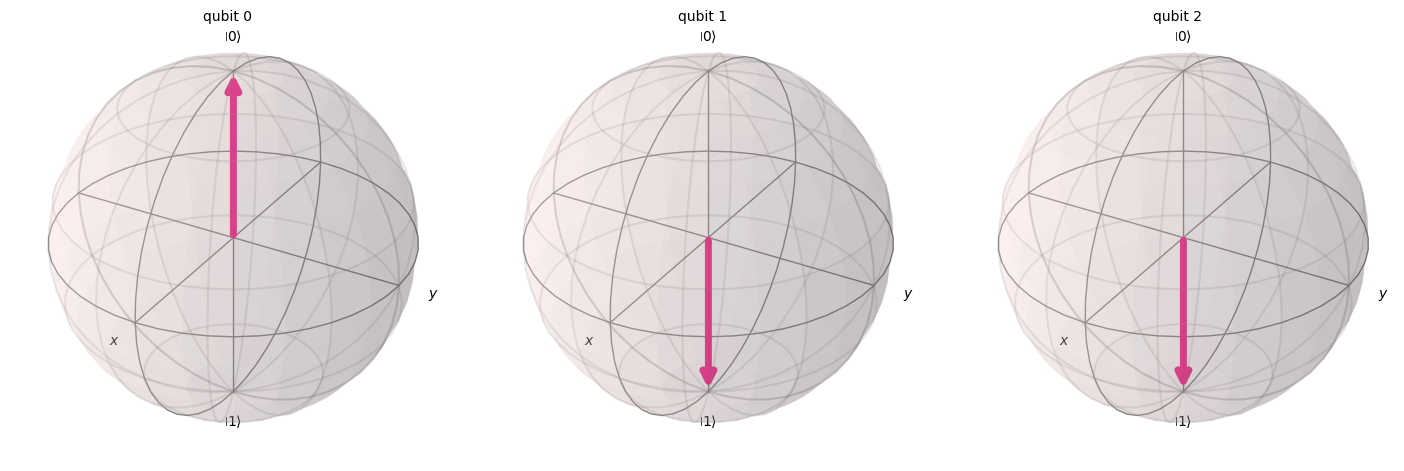

In [76]:
sv_sim = Aer.get_backend('statevector_simulator')
out_vector = sv_sim.run(teleportation_circuit).result().get_statevector()
plot_bloch_multivector(out_vector)

<p>&#128211;What do you observe when looking at qubit 2? Has the state $|\psi_B \rangle = |1\rangle$ been teleported to $|q_2\rangle$? If the answer is no, explain the reason. (1 point)

**Your answer:** No, the state has not been teleported. That is because the bell state has been changed.

<h4 style="font-size: 17px">&#128211;Changing the corrections.</h4>

As you might have realised, when changing the Bell pair the corrections that Bob was applying are not valid anymore.

<p>&#128211;Let's then calculate the new operations that Bob will have to perform to get Alice's qubit ($|\psi \rangle = |1\rangle$).
To do so, you will first have to calculate by hand what the state of the 3-qubit system is right before Alice measure her two qubits. (1 point)


**Your answer:**

|q<sub>2</sub>q<sub>1</sub>q<sub>0</sub>⟩ = |001⟩

Hq<sub>1</sub> = $\frac{1}{\sqrt{2}}$(|001⟩ + |011⟩)

Xq<sub>2</sub> = $\frac{1}{\sqrt{2}}$(|101⟩ + |111⟩)

CNOT<sub>q<sub>1</sub>q<sub>2</sub></sub> = $\frac{1}{\sqrt{2}}$(|101⟩ + |011⟩)

CNOT<sub>q<sub>0</sub>q<sub>1</sub></sub> = $\frac{1}{\sqrt{2}}$(|111⟩ + |001⟩)

Hq<sub>0</sub> = $\frac{1}{2}$(|110⟩ − |111⟩ + |000⟩ − |001⟩)


<p>&#128211;Based on the state you just calculated, what are the new corrections (transformations) Bob needs to apply? (1 point)

**Your answer:** Bob needs to reverse the condition of x gate application

Modify now the `bob_gates` function based on the new corrections you have derived and show that now the state $|\psi \rangle = |1\rangle$ has been indeed teleported to qubit 2. Please, run the visualization code several times and take some snapshots of the Bloch spheres for different outcomes of qubits $|q_0\rangle$ and $|q_1\rangle$. (2 points)

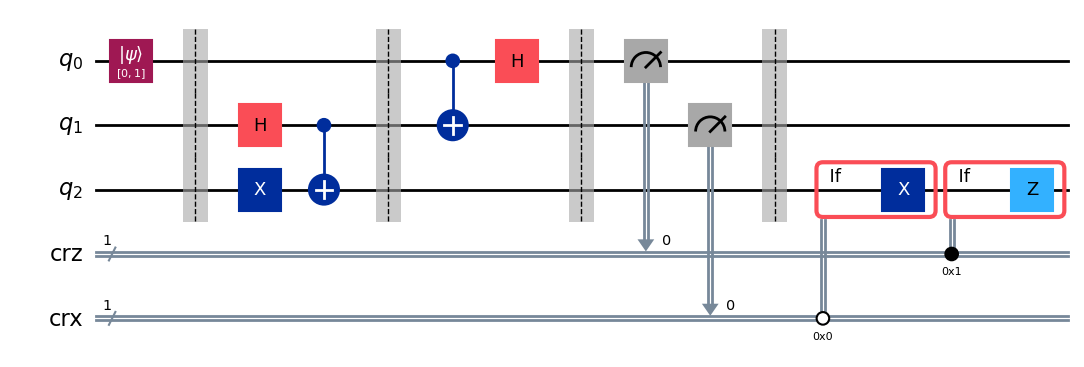

In [87]:

#### your code goes here

#### your code goes here

qr = QuantumRegister(3, name='q')
crz, crx = ClassicalRegister(1, name="crz"), ClassicalRegister(1, name="crx")
teleportation_circuit = QuantumCircuit(qr,crz,crx)

## STEP1: initialization of the qubit to be sent (Alice's qubit)

#initial state A
initial_stateA = [1,0]

#initial state B
initial_stateB = [0,1]

#initial state C
initial_stateC = [1/2, sqrt(3)/2]

#initial state D
initial_stateD= random_statevector(2, seed = 2137)

#Apply initialisation operation to the 0th qubit
teleportation_circuit.initialize(initial_stateB, 0)
teleportation_circuit.barrier()


## STEP2: Creation of the Bell Pair
#### your code goes here

teleportation_circuit.h(1)
teleportation_circuit.x(2)
teleportation_circuit.cx(1,2)

teleportation_circuit.barrier()

## STEP3: Operations and measurements at Alice's side (CNOT and H)
#### your code goes here

teleportation_circuit.cx(0,1)
teleportation_circuit.h(0)

teleportation_circuit.barrier()

#measurements of qubits 0 and 1 see: https://docs.quantum.ibm.com/guides/measure-qubits
#### your code goes here

teleportation_circuit.measure(0, crz)
teleportation_circuit.measure(1, crx)

teleportation_circuit.barrier()

## STEP4: Corrections

#After receiving the two clasical bits, Bob will have to apply specific corrections to his qubit. These corrections are:
#00  →  Do nothing
#01  →  Apply  𝑋  gate
#10  →  Apply  𝑍  gate
#11  →  Apply  𝑍𝑋  gate

# Check the if_test instruction of Qiskit por performing the corrections https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit

#### your code goes here

with teleportation_circuit.if_test((crx, 0)) as else_:
    teleportation_circuit.x(2)
with teleportation_circuit.if_test((crz, 1)) as else_:
    teleportation_circuit.z(2)


teleportation_circuit.draw()


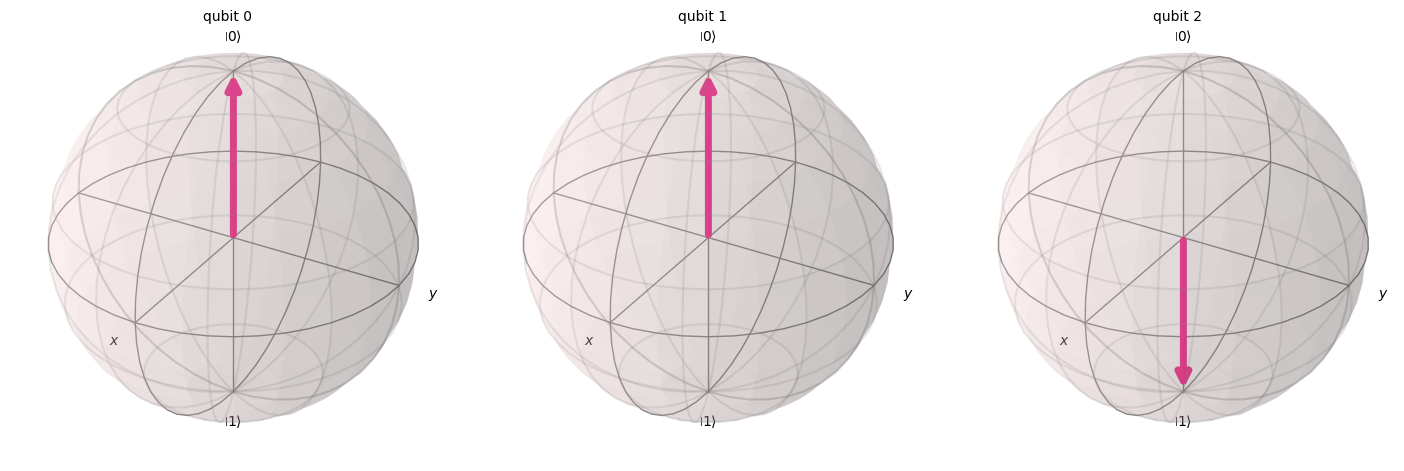

In [90]:
sv_sim = Aer.get_backend('statevector_simulator')
out_vector = sv_sim.run(teleportation_circuit).result().get_statevector()
plot_bloch_multivector(out_vector)